# Logistic Regression implementation without Scikit-learn


In [80]:
import numpy as np
import pandas as pd

from scipy.stats import norm
from sklearn.datasets import make_blobs

from matplotlib import pyplot
import matplotlib.pyplot as plt

import matplotlib.cm as cm
from random import sample

## Generating Some Example Data with 2 Features

In [81]:
n_feature = 3 # the number of features
n_components = 2 # the number of clusters

n=1000 # the number of total samples

In [82]:
# generate isotropic Gaussian blobs (data from mixture Gaussian distributions)
X, y = make_blobs(n_samples=n, # the number of total samples
                  centers=n_components, # the number of clusters
                  n_features=n_feature, # the number of features
                  cluster_std = [5] * n_components, # the std of each cluster
                  random_state=2) # 2

# X = np.hstack((np.ones((m, 1)), X))



In [83]:
for i in range(5):
    print('x =', X[i, ], ', y =', y[i])

x = [-2.8644827  -3.62428519 -7.36167995] , y = 1
x = [ -6.26490039 -10.79841575  -2.3935529 ] , y = 0
x = [ 4.58359706  4.50563332 -4.90754099] , y = 1
x = [0.70277947 9.14180788 3.53957977] , y = 1
x = [-0.78081564  2.64002493 -2.83012691] , y = 1


In [84]:
# Just to show you what is inside it. We print the first 10 elements of this numpy array. 
y[:10]

array([1, 0, 1, 1, 1, 1, 0, 0, 0, 0])

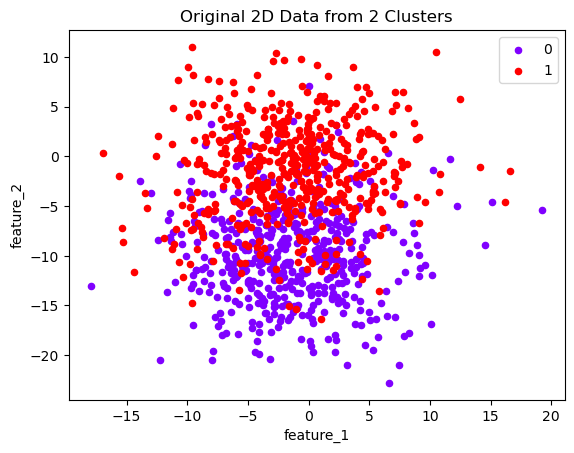

In [85]:
# scatter plot, data points annotated by different colors
df = pd.DataFrame(dict(feature_1=X[:,0], feature_2=X[:,1], label=y))


cluster_name = set(y)
colors = dict(zip(cluster_name, cm.rainbow(np.linspace(0, 1, len(cluster_name)))))
fig, ax = pyplot.subplots()

grouped = df.groupby('label')

for key, group in grouped:
    group.plot(ax=ax, kind='scatter', x='feature_1', y='feature_2', label=key, color=colors[key].reshape(1,-1))
    
pyplot.title('Original 2D Data from {} Clusters'.format(n_components))
pyplot.show()

In [86]:
df = pd.read_csv("Heart copy.csv")
X = df[['Age', 'Sex', 'Chol']].values
#X = (X - X.mean(axis=0)) / X.std(axis=0)

df['Target'] = df['Target'].map({'No': 0, 'Yes': 1})
y = df['Target'].values
# Create Test/Train
# from sklearn.model_selection import train_test_split

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

np.random.seed(120)
i = np.random.permutation(len(X)) #random order of indices
split = int(0.8 * len(X))

train_index = i[:split]
test_index = i[split:]

X_train = X[train_index]
X_test = X[test_index]
y_train = y[train_index]
y_test = y[test_index]

In [87]:
def sigmoid(z):
    """
    To convert continuous value into a range of 0 to 1

    I/P
    ----------
    z : Continuous value

    O/P
    -------
    Value in range between 0 to 1.
    """
    g = 1 / (1 + np.exp(-z))
    return g

In [88]:
def cost_function(X, y, weights):
    """
    Compute cost for logistic regression.

    I/P
    ----------
    X : 2D array where each row represent the training example and each column represent the feature ndarray. 
        Dimension(m x n)
        m= number of training examples
        n= number of features (including X_0 column of ones)
    y : 1D array of labels/target value for each traing example. dimension(1 x m)

    weights : 1D array of fitting parameters or weights. Dimension (1 x n)

    O/P
    -------
    cost : The cost of using theta as the parameter for logistic regression to fit the data points in X and y.
    """
    m, n = X.shape
    x_dot_weights = X.dot(weights)

    cost = 1.0 / m * (-y.T.dot(np.log(sigmoid(x_dot_weights))) - (1 - y).T.dot(np.log(1 - sigmoid(x_dot_weights))))

    return cost

In [89]:
def gradient(X, y, weights):
    """
    Compute gradient for logistic regression.

    I/P
    ----------
    X : 2D array where each row represent the training example and each column represent the feature ndarray. 
    Dimension(m x n)
        m = number of training examples
        n = number of features (including X_0 column of ones)
    y : 1D array of labels/target value for each traing example. dimension(1 x m)

    weights : 1D array of fitting parameters or weights. Dimension (1 x n)

    O/P
    -------
    grad: (numpy array)The gradient of the cost with respect to the parameters theta
    """
    m, n = X.shape
    x_dot_weights = X.dot(weights)

    grad = (1.0 / m )* (sigmoid(x_dot_weights) - y).T.dot(X)

    return grad

In [90]:
weights = np.zeros(n_feature)


cost = cost_function(X_train, y_train, weights)
grad = gradient(X_train, y_train, weights)

print(cost)
print(grad)

0.6931471805599451
[ 0.64049587 -0.03719008  4.95661157]


In [91]:
# Now we optimize it using Gradient Descent. 
num_iterations = 100
learnin_rate = 0.0001

cost_list = []

for i in range(0, num_iterations):
    
    cost = cost_function(X_train, y_train, weights)
    print("Cost is: ", cost)
    cost_list.append(cost)
    
    grad = gradient(X_train, y_train, weights)
    
    weights = weights - learnin_rate * grad    

Cost is:  0.6931471805599451
Cost is:  0.6926956286925025
Cost is:  0.692494333672984
Cost is:  0.6924012567867449
Cost is:  0.6923525586813779
Cost is:  0.6923228182803391
Cost is:  0.6923010304452705
Cost is:  0.6922826733509536
Cost is:  0.6922658230631474
Cost is:  0.6922496786495989
Cost is:  0.6922339014959269
Cost is:  0.6922183494422115
Cost is:  0.6922029621277592
Cost is:  0.6921877136959769
Cost is:  0.6921725927312673
Cost is:  0.6921575938915607
Cost is:  0.6921427143867573
Cost is:  0.692127952501153
Cost is:  0.692113306975028
Cost is:  0.6920987767436231
Cost is:  0.6920843608286936
Cost is:  0.6920700582922326
Cost is:  0.6920558682175119
Cost is:  0.6920417897007799
Cost is:  0.6920278218479495
Cost is:  0.6920139637730455
Cost is:  0.6920002145976056
Cost is:  0.6919865734503421
Cost is:  0.6919730394670047
Cost is:  0.6919596117902672
Cost is:  0.6919462895696646
Cost is:  0.6919330719615251
Cost is:  0.6919199581289183
Cost is:  0.6919069472415968
Cost is:  0.69189

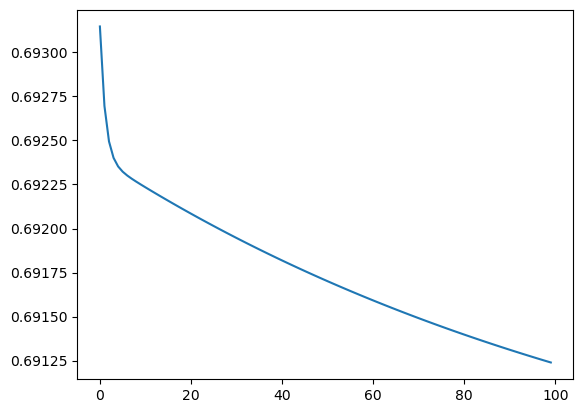

In [92]:
plt.plot(np.arange(num_iterations), cost_list)
plt.show()

In [93]:
def predict(weights, X):
    """
    Predict the class between 0 and 1 using learned logistic regression parameters weights.
    Using threshold value 0.5 to convert probability value to class value 

    I/P
    ----------
    X : 2D array where each row represent the training example and each column represent the feature ndarray. 
        Dimension(m x n)
        m= number of training examples
        n= number of features (including X_0 column of ones)

    theta : 1D array of fitting parameters or weights. Dimension (1 x n)

    O/P
    -------
    Class type based on threshold
    """
    p = sigmoid(X.dot(weights)) >= 0.5
    return p.astype(int)

In [94]:
predictions = predict(weights, X_test)
predictions

array([0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [95]:
y_test

array([1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0])

In [96]:
# Correct Predictions are the cases that are equal. 

correct = np.sum(predictions == y_test)


print("Accuracy is: ", correct/y_test.size)


Accuracy is:  0.6229508196721312


In [97]:
true_pos = np.sum((predictions == 1) & (y_test == 1))
true_neg = np.sum((predictions == 0) & (y_test == 0))
false_pos = np.sum((predictions == 1) & (y_test == 0))
false_neg = np.sum((predictions == 0) & (y_test == 1))

accuracy  = (true_pos + true_neg) / len(y_test)
precision = true_pos / (true_pos + false_pos)
recall    = true_pos / (true_pos + false_neg)
f1        = 2 * (precision * recall) / (precision + recall)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.6230
Precision: 0.6667
Recall: 0.1600
F1 Score: 0.2581
